  PRICING OPTIONS EUR/USD
  Spot     : 1.135
  Strike   : 1.1432
  Sigma    : 6.16%
  Maturite : 3 mois
  r (USD)  : 2.60%
  q (EUR)  : -0.31%

  Prime Call (B&S) : 0.01400
  Prime Put  (B&S) : 0.01391
  Delta Call       : 0.50752
  Delta Put        : -0.49325
  Gamma            : 11.41907

──────────────────────────────────────────────────
  MONTE CARLO
──────────────────────────────────────────────────
  Prime Call Monte Carlo (N=100,000) : 0.01413
  Prime Call Black-Scholes        : 0.01400
  Erreur relative : 0.921%
  1/sqrt(N)       : 0.316%


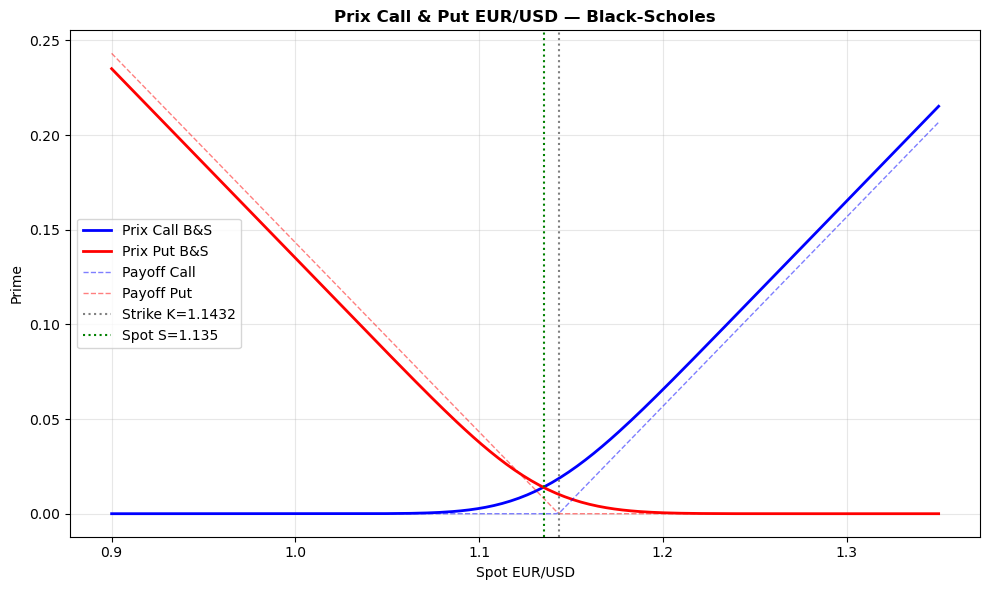


Graphique sauvegarde : Pricing_Options_Graphique.png


In [3]:
# Black Scholes pour Devise (Garman Kohlhagen) et les lettres grecques

import math
from math import sqrt, log, exp
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import norm
from random import random

# PARAMETRES DE MARCHE

S     = 1.135       # Spot EURUSD
K     = 1.1432      # Strike
sigma = 6.16/100    # Volatilité
T     = 0.25        # Maturité : 3 mois
r     = 2.60/100    # Taux sans risque $
q     = -0.31/100   # Taux sans risque €

print("=" * 50)
print("  PRICING OPTIONS EUR/USD")
print("=" * 50)
print(f"  Spot     : {S}")
print(f"  Strike   : {K}")
print(f"  Sigma    : {sigma*100:.2f}%")
print(f"  Maturite : {T*12:.0f} mois")
print(f"  r (USD)  : {r*100:.2f}%")
print(f"  q (EUR)  : {q*100:.2f}%")

# FORMULES BLACK SCHOLES


def d_un(S, K, sigma, T, r, q):
    d1 = (1/(sigma*sqrt(T))) * (log(S/K) + (r - q + (sigma**2)/2) * T)
    return d1

def d_deux(S, K, sigma, T, r, q):
    d2 = d_un(S, K, sigma, T, r, q) - (sigma*sqrt(T))
    return d2

def bs_call(S, K, sigma, T, r, q):
    d1 = d_un(S, K, sigma, T, r, q)
    d2 = d_deux(S, K, sigma, T, r, q)
    N_d1 = stats.norm.cdf(d1, 0, 1)
    N_d2 = stats.norm.cdf(d2, 0, 1)
    op_call = (S*exp(-q*T)*N_d1) - (K*exp(-r*T)*N_d2)
    return op_call

def bs_put(S, K, sigma, T, r, q):
    d1 = d_un(S, K, sigma, T, r, q)
    d2 = d_deux(S, K, sigma, T, r, q)
    N_nd1 = stats.norm.cdf(-d1, 0, 1)
    N_nd2 = stats.norm.cdf(-d2, 0, 1)
    op_put = (-S*exp(-q*T)*N_nd1) + (K*exp(-r*T)*N_nd2)
    return op_put

def delta_call(S, K, sigma, T, r, q):
    d1 = d_un(S, K, sigma, T, r, q)
    N_d1 = stats.norm.cdf(d1, 0, 1)
    return exp(-q*T) * N_d1

def delta_put(S, K, sigma, T, r, q):
    d1 = d_un(S, K, sigma, T, r, q)
    N_d1 = stats.norm.cdf(d1, 0, 1)
    return exp(-q*T) * (N_d1 - 1)

def bs_gamma(S, K, sigma, T, r, q):
    d1 = d_un(S, K, sigma, T, r, q)
    Np_d1 = stats.norm.pdf(d1, 0, 1)
    return (Np_d1 * exp(-q*T)) / (S * sigma * sqrt(T))

# Calcul et affichage des resultats B&S
prime_call   = bs_call(S, K, sigma, T, r, q)
prime_put    = bs_put(S, K, sigma, T, r, q)
delta_call_v = delta_call(S, K, sigma, T, r, q)
delta_put_v  = delta_put(S, K, sigma, T, r, q)
v_gamma      = bs_gamma(S, K, sigma, T, r, q)

print(f"\n  Prime Call (B&S) : {prime_call:.5f}")
print(f"  Prime Put  (B&S) : {prime_put:.5f}")
print(f"  Delta Call       : {delta_call_v:.5f}")
print(f"  Delta Put        : {delta_put_v:.5f}")
print(f"  Gamma            : {v_gamma:.5f}")

# SIMULATION MONTE CARLO

print(f"\n{'─'*50}")
print(f"  MONTE CARLO")
print(f"{'─'*50}")

def VarGaussienne():
    a = random()
    return norm.ppf(a, 0, 1)

def FwdGBM(S, mu, sigma, T, vg):
    Fwd = S * exp((mu - sigma**2/2)*T + sigma*sqrt(T)*vg)
    return Fwd

def MaxSK_Call(S, K):
    if S >= K:
        return S - K
    else:
        return 0

mu = r - q

N = 100000
PrimeSomme = 0

for i in range(0, N):
    vg  = VarGaussienne()
    fwd = FwdGBM(S, mu, sigma, T, vg)
    PrimeSomme = PrimeSomme + MaxSK_Call(fwd, K)

PrimeCall_MC = exp(-r*T) * (PrimeSomme / N)

print(f"  Prime Call Monte Carlo (N={N:,}) : {PrimeCall_MC:.5f}")
print(f"  Prime Call Black-Scholes        : {prime_call:.5f}")
print(f"  Erreur relative : {abs(PrimeCall_MC - prime_call)/prime_call*100:.3f}%")
print(f"  1/sqrt(N)       : {100/sqrt(N):.3f}%")

# GRAPHIQUE — Prix Call et Put vs Spot

spots = np.linspace(0.90, 1.35, 200)
calls = [bs_call(s, K, sigma, T, r, q) for s in spots]
puts  = [bs_put(s, K, sigma, T, r, q) for s in spots]
pay_c = [max(s - K, 0) for s in spots]
pay_p = [max(K - s, 0) for s in spots]

plt.figure(figsize=(10, 6))
plt.plot(spots, calls, 'b-',  lw=2,           label='Prix Call B&S')
plt.plot(spots, puts,  'r-',  lw=2,           label='Prix Put B&S')
plt.plot(spots, pay_c, 'b--', lw=1, alpha=0.5, label='Payoff Call')
plt.plot(spots, pay_p, 'r--', lw=1, alpha=0.5, label='Payoff Put')
plt.axvline(x=K, color='gray',  linestyle=':', label=f'Strike K={K}')
plt.axvline(x=S, color='green', linestyle=':', label=f'Spot S={S}')
plt.title('Prix Call & Put EUR/USD — Black-Scholes',
          fontsize=12, fontweight='bold')
plt.xlabel('Spot EUR/USD')
plt.ylabel('Prime')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Pricing_Options_Graphique.png', dpi=150)
plt.show()
print("\nGraphique sauvegarde : Pricing_Options_Graphique.png")